In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler


#notebook aesthetics
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")


/home/jeremiah/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
url = "https://raw.githubusercontent.com/MarcCollado/wine/master/wineQualityReds.csv"
df = pd.read_csv(url)
df.head()

,Unnamed: 0,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
0,1,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,2,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,3,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,4,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,5,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.tail()

,Unnamed: 0,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
1594,1595,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,1596,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,1597,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,1598,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,1599,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [7]:
#How many observations and features are available?
#What datatypes are present?
#Are there missing or duplicate records?
#What is the distribution of the target variable?
#Are there obvious data quality issues that require preprocessing? 

In [9]:
#how large is the dataset?
df.shape

(1599, 13)

In [11]:
#dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            1599 non-null   int64  
 1   fixed.acidity         1599 non-null   float64
 2   volatile.acidity      1599 non-null   float64
 3   citric.acid           1599 non-null   float64
 4   residual.sugar        1599 non-null   float64
 5   chlorides             1599 non-null   float64
 6   free.sulfur.dioxide   1599 non-null   float64
 7   total.sulfur.dioxide  1599 non-null   float64
 8   density               1599 non-null   float64
 9   pH                    1599 non-null   float64
 10  sulphates             1599 non-null   float64
 11  alcohol               1599 non-null   float64
 12  quality               1599 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 162.5 KB


In [13]:
#Summary statistics
df.describe()

,Unnamed: 0,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,800.000000,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,461.735855,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,1.000000,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,400.500000,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,800.000000,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,1199.500000,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,1599.000000,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1599.0,800.000000,461.735855,1.00000,400.5000,800.00000,1199.500000,1599.00000
fixed.acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile.acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric.acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual.sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free.sulfur.dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total.sulfur.dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000


In [17]:
#which variables have the largest spread? std -> how spread out the data is from the mean 
#which variables are highly skewed
#are there impossible values?
#which features may require scaling


In [19]:
df.duplicated().sum()

0

In [21]:
#target variable distribution
df["quality"].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [23]:
df["quality"].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

/tmp/ipykernel_12587/160024113.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Text(0, 0.5, 'Count')

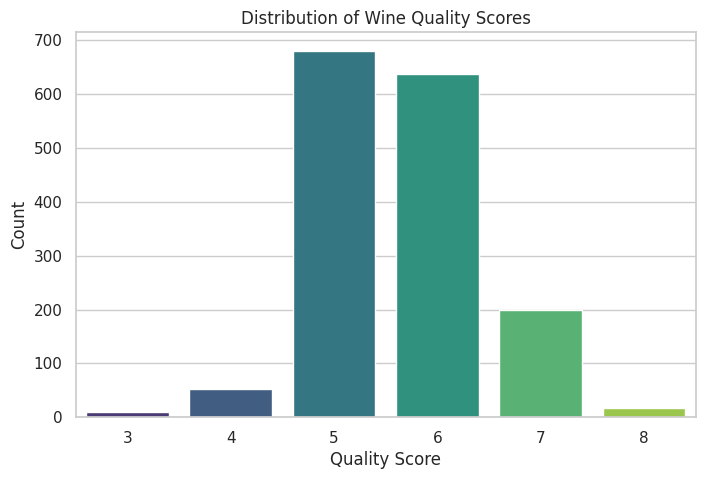

In [25]:
#visualizing target variable distribution
plt.figure(figsize=(8,5))

sns.countplot(
    data = df,
    x = "quality",
    palette = "viridis",
)

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Count")

In [26]:
#is the dataset balanced?
#which quality scores are more common?
#are extreme quality levels rare? 
#could class imbalance become an issue later?

In [30]:
#'WHAT STORY IS THE DATA TELLING US' PHASE#
#EDA


In [32]:
#which features exhibit greatest variability?
#are there significant outliers that could affect distance-based methods like MDS?
#which variables are strongly correlated?
#do certain chemical properties appear to influence wine quality?
#are there observable patterns that suggest natural grouping of wine?


"""
Class imbalance in machine learning occurs when one class in a dataset significantly outnumbers the other(s).
For example, in credit card fraud detection, valid transactions might make up 99.9% of the data,
leaving fraudulent transactions as the rare 0.1%

you can use resampling techniques or cost-sensitive learning to reduce the effects of class imbalance
"""


'\nClass imbalance in machine learning occurs when one class in a dataset significantly outnumbers the other(s).\nFor example, in credit card fraud detection, valid transactions might make up 99.9% of the data,\nleaving fraudulent transactions as the rare 0.1%\n\nyou can use resampling techniques or cost-sensitive learning to reduce the effects of class imbalance\n'

In [34]:
features = df.columns.drop("quality")

In [36]:
features

Index(['Unnamed: 0', 'fixed.acidity', 'volatile.acidity', 'citric.acid',
       'residual.sugar', 'chlorides', 'free.sulfur.dioxide',
       'total.sulfur.dioxide', 'density', 'pH', 'sulphates', 'alcohol'],
      dtype='str')

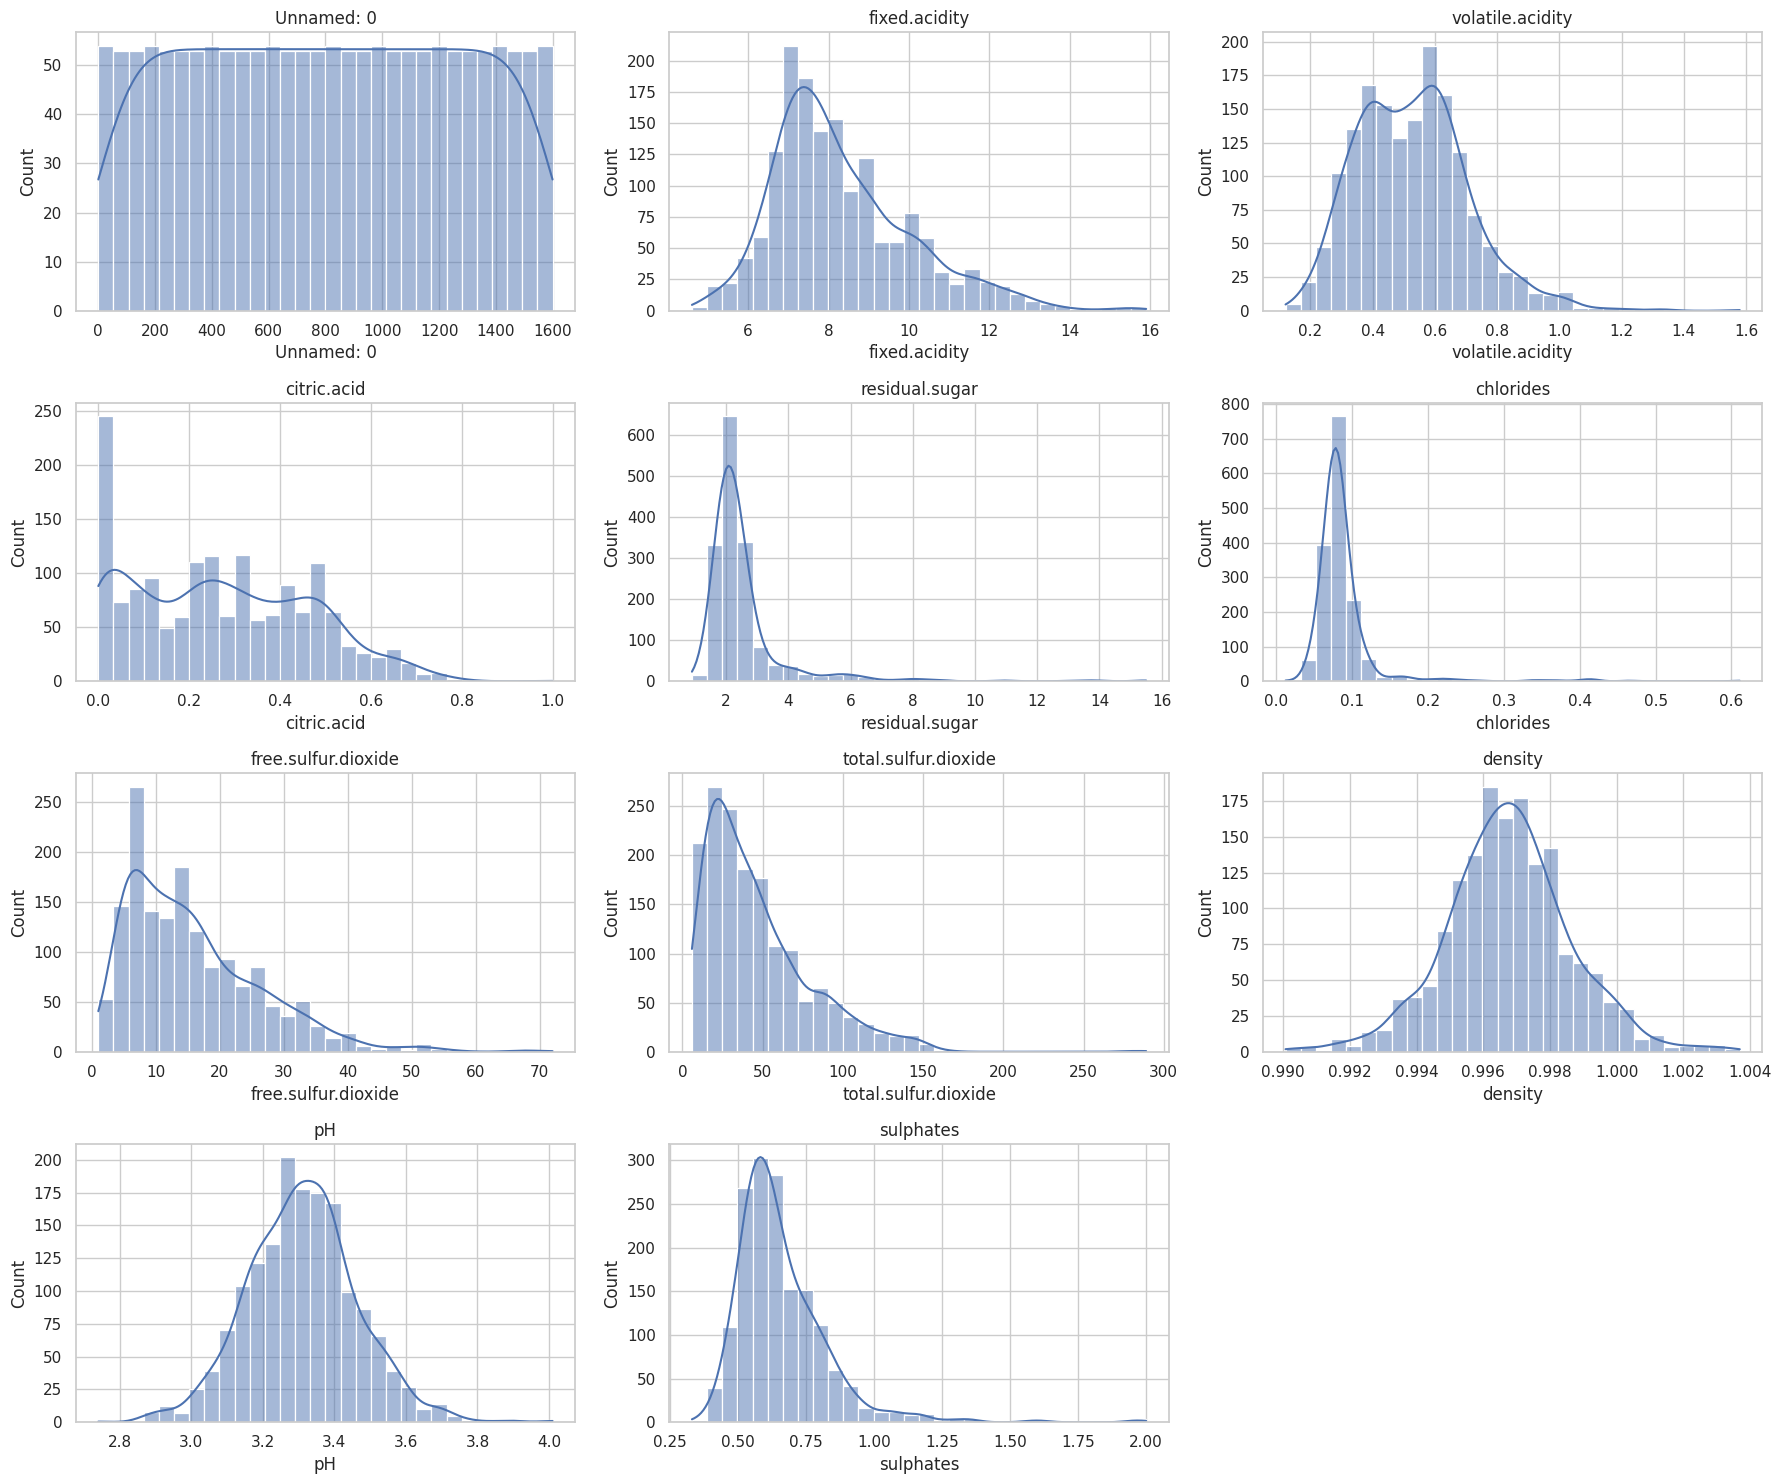

In [38]:
fig, axes = plt.subplots(4, 3, figsize=(18,15))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(
        df[feature],
        bins=30,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(feature)

#remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()

In [39]:
#for every histogram
# - is the distribution symmetric?
# - is it skewed?
# - are there multiple peaks
# - does the feature contain extreme values?

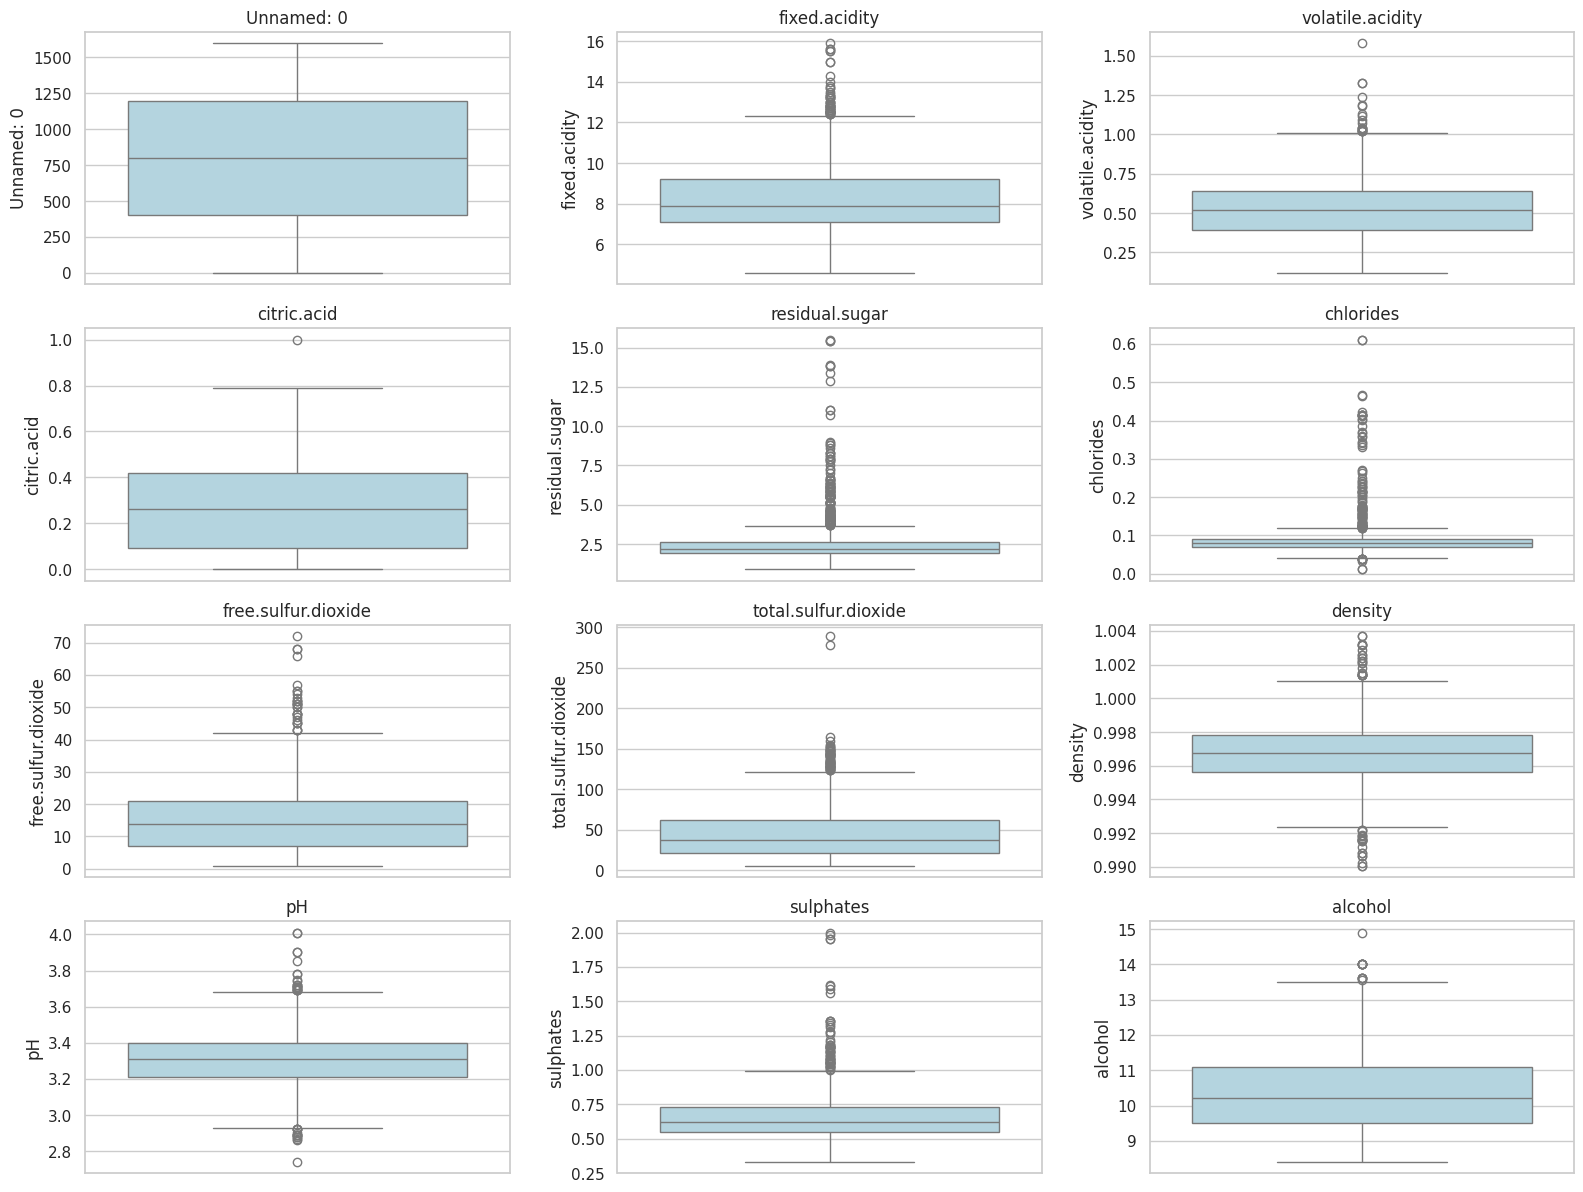

In [40]:
#outlier detections
plt.figure(figsize=(16,12))

for i, feature in enumerate(features, 1):
    plt.subplot(4,3,i)

    sns.boxplot(
        y=df[feature],
        color="lightblue",
    )
    plt.title(feature)

plt.tight_layout()

In [41]:
#on the outliers:-
#are these measurement errors?
#are they legitimate but rare wines?
#could they distort pairwise distances?


#since this laboratory data, many extreme values are likely to represent genuine observations rather than mistakes


Text(0.5, 1.0, 'Correlation Matrix')

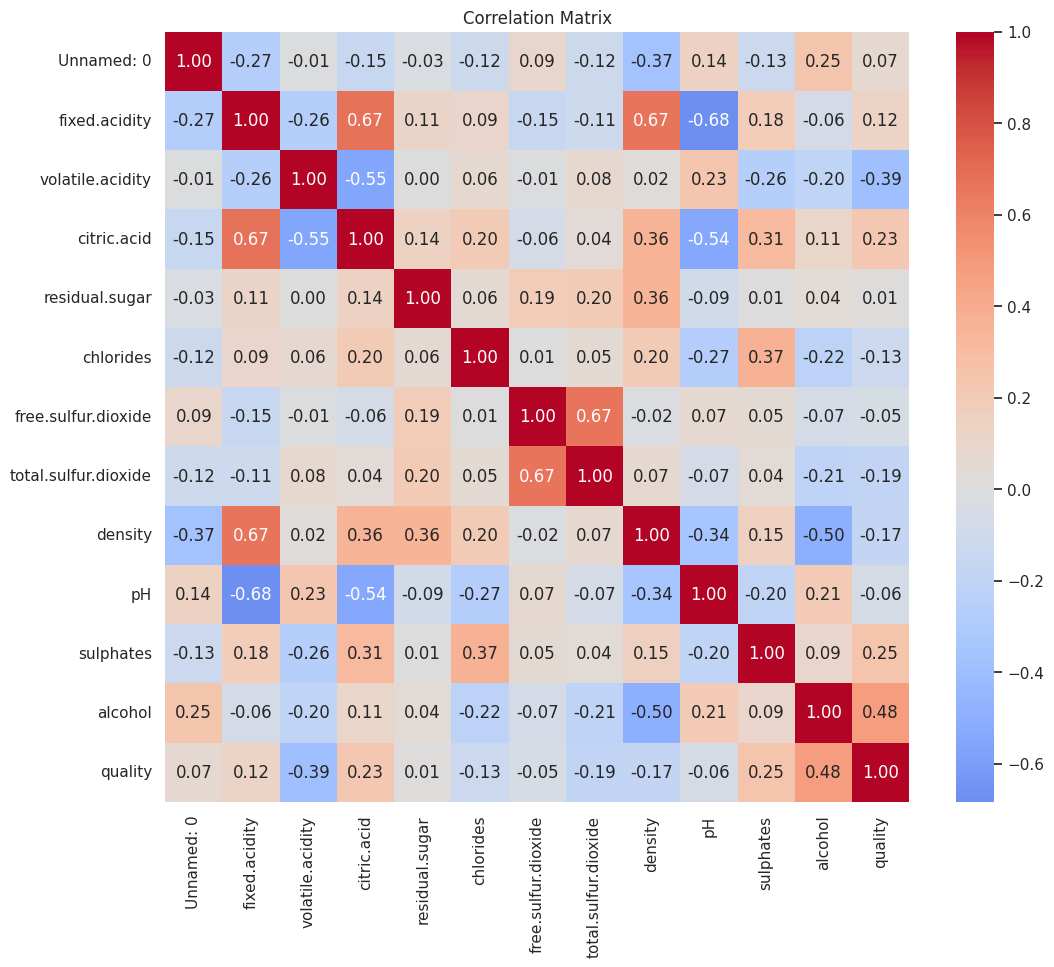

In [42]:
#Correlation Analysis

#one of the most informative parts of EDA

plt.figure(figsize=(12,10))

corr = df.corr(numeric_only = True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
)

plt.title("Correlation Matrix")


In [43]:
"""
most significant correlations (|+0.30 - +1.0|, |-1.0 - -0.3|)
"""
#fixed acidity na citric acid = +0.67
#volatile acidity na citric acid = -0.55
#density na fixed acidity  = +0.67
#pH na fixed acidity = -0.68
#pH na citric acid = -0.54
#density na residual sugar = +0.36
#sulphates na chlorides = +0.37
#total sulpur dioxide na free sulpher dioxide = +0.67 
#citric acid na density = +0.36
#residual sugar na density = +0.36
#pH na density = -0.34
#alcohol na density = -0.50

#quality na alcohol = +0.48
#volatile acidity na quality = -0.39


'\nmost significant correlations (|+0.30 - +1.0|, |-1.0 - -0.3|)\n'

In [44]:
#Questions
#identify:
# - strongest positive correlations => [fixed acidity na citric acid = +0.67, density na fixed acidity  = +0.67, total sulpur dioxide na free sulpher dioxide = +0.67]
# - strongest negative correlations => [volatile acidity na citric acid = -0.55, pH na fixed acidity = -0.68, pH na citric acid = -0.54, alcohol na density = -0.50]
# - variables weakly related to everything => [residual sugar*, chlorides*, ] residual sugar & density=>+0.36, chlorides & sulphates = +0.37
# - variables correlated with quality => [volatile acidity & quality => -0.39]


In [45]:
#Selecting features for pairwise analysis
"""
How can a professional select the best features?
1 - Business objective  -which variables matter for the problem we are trying to solve?
2 - Domain knowledge - which measurements are known to influence the target?
3 - Correlation Analysis - which features are most related to the target?
4 - feature distribution and variance - which variables show enough variation to be informative?
5 - Redundancy Analysis - Are some features essentiallyt duplicates of others?

"""
#for this case, let's rank the features interms of their correlation with the target

corr_quality = (
    df.corr(numeric_only=True)["quality"].drop("quality").sort_values(key=abs, ascending=False)
)
corr_quality

alcohol                 0.476166
volatile.acidity       -0.390558
sulphates               0.251397
citric.acid             0.226373
total.sulfur.dioxide   -0.185100
density                -0.174919
chlorides              -0.128907
fixed.acidity           0.124052
Unnamed: 0              0.066453
pH                     -0.057731
free.sulfur.dioxide    -0.050656
residual.sugar          0.013732
Name: quality, dtype: float64

In [54]:
#now we select the top features
top_features = corr_quality.head(4)
top_features

alcohol             0.476166
volatile.acidity   -0.390558
sulphates           0.251397
citric.acid         0.226373
Name: quality, dtype: float64

In [56]:
top_features.index.to_list()

['alcohol', 'volatile.acidity', 'sulphates', 'citric.acid']

In [58]:
t_features = top_features.index.to_list()

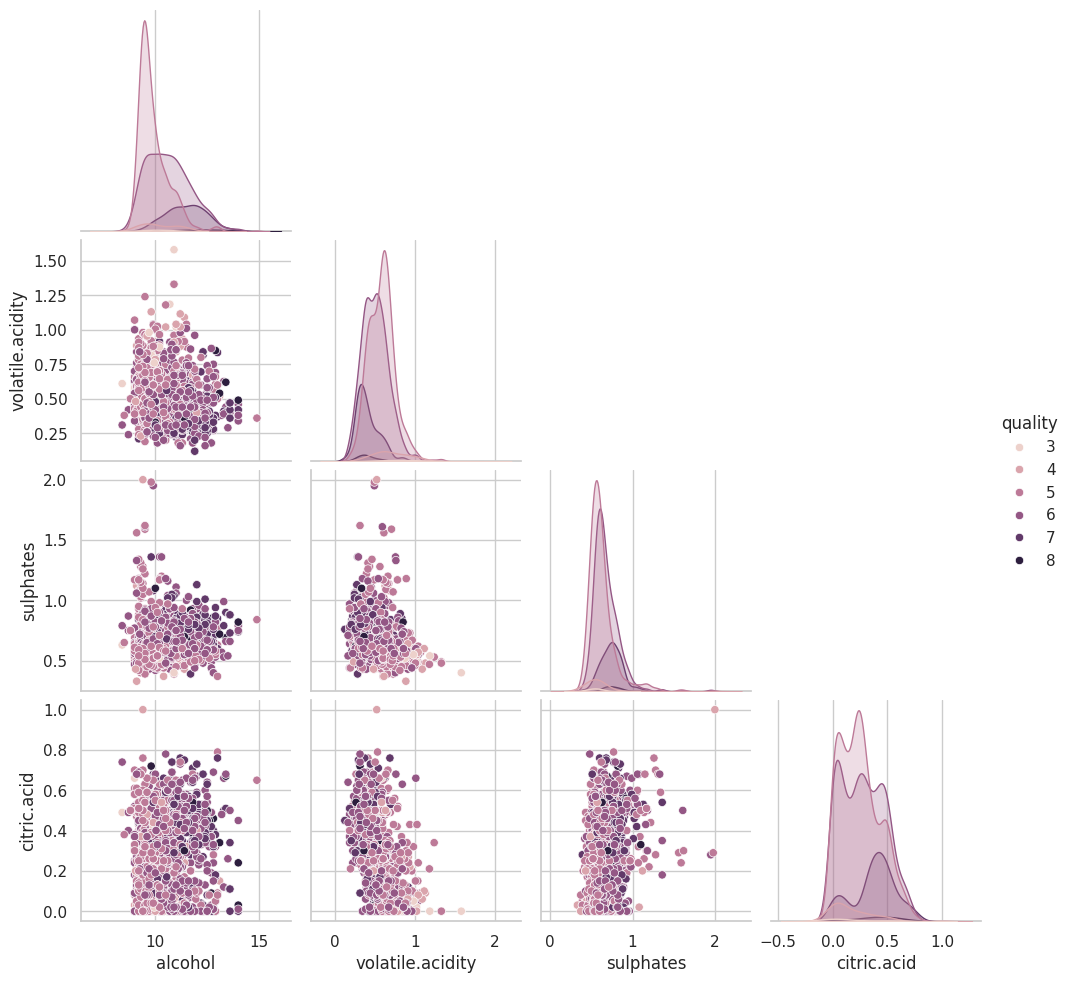

In [60]:
#Pairwise relationships 
selected = t_features + ["quality"]

sns.pairplot(
    df[selected],
    hue="quality",
    corner=True
    
)

In [61]:
#feature vs quality
#we investigate which chemical qualities (features) affect wine quality


Text(0.5, 1.0, 'Alcohol content across wine quality')

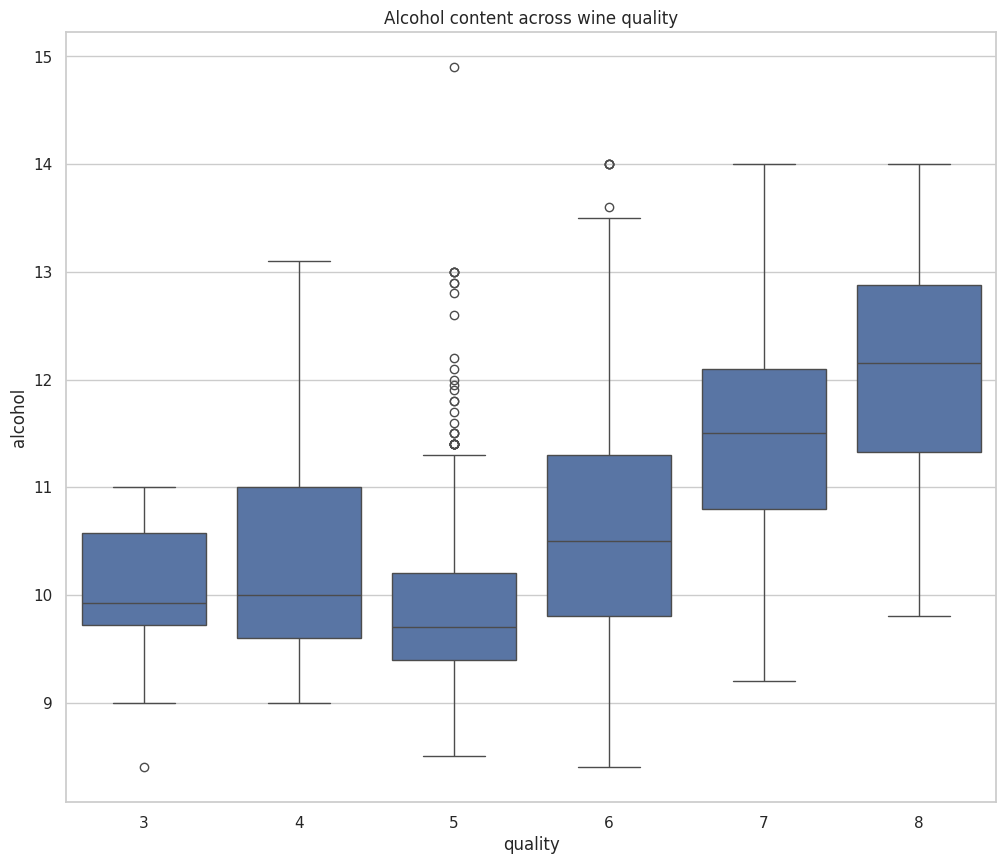

In [62]:
#we begin with alcohol
plt.figure(figsize=(12,10))
sns.boxplot(
    data=df,
    x="quality",
    y="alcohol",
)

plt.title("Alcohol content across wine quality")

In [63]:
#wine quality does increase with alcohol quantity

<Axes: xlabel='quality', ylabel='volatile.acidity'>

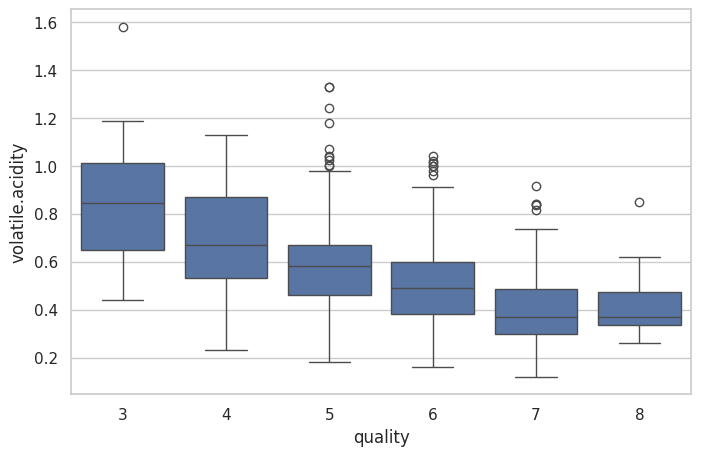

In [64]:
#volatile acidity
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    y="volatile.acidity",
    x="quality"
)

In [65]:

#wine quality does indeed decrease with an increase in volatice acidity

<Axes: xlabel='quality', ylabel='sulphates'>

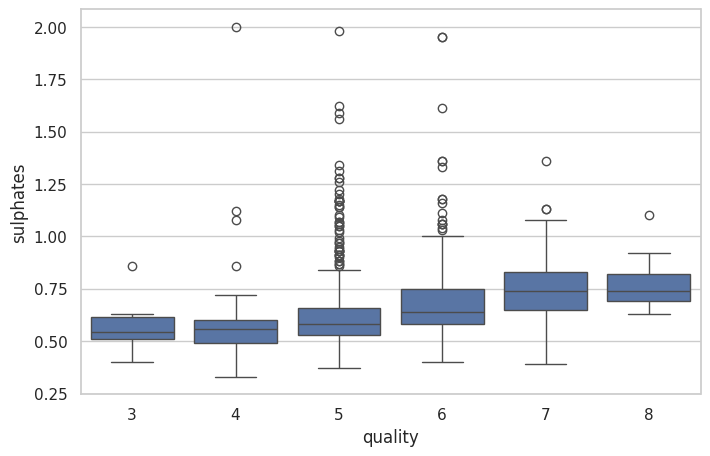

In [66]:
#sulphates
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="quality",
    y="sulphates"
)

In [67]:
#there is a slightly complicated relationship here but generally wine quality does increase with an increase with an increase with sulphates

##while the relationship is slightly compplex at the extremes,higher wine quality is generally associated with an increase in median 
#sulphate levels particularly between quality scores of 4 and 7
#

<Axes: xlabel='quality', ylabel='citric.acid'>

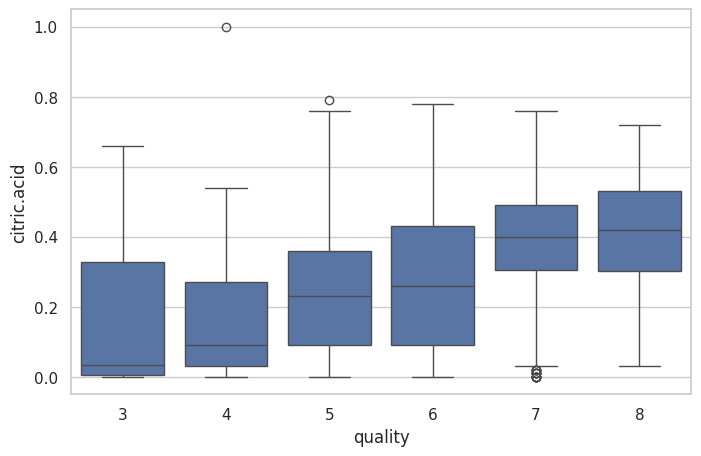

In [76]:

#citric.acid

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="quality",
    y="citric.acid"
)

In [77]:
#box plot analysis reveals a clear positive relationship between wine quality and citric acid concentrations.
#median citric acid rises steadily from 0.09 in quality 4 to 0.42 in quality 8. Further more the inequality range 
#shifts upwards for premium categories (7-8), where 75% of observations exceed ~0.30 citric acid.

#wine quality is positively associated with citric acid content. Higher-rated wines (quality 7 and 8 ) concistently exhibit higher citric
#acid levels with medians around 0.40 compared to lower quality ratings (quality 3 and 4) where medians  drop below 0.10.

<Axes: xlabel='quality', ylabel='density'>

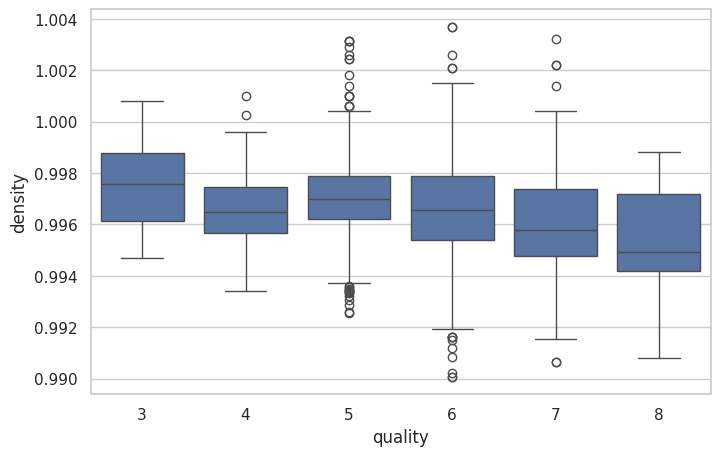

In [80]:
#density
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="quality",
    y="density"
)

In [82]:

#are higher quality wines chemically distinct?


In [84]:
"""
1. Majority of wines have a quality score between 5 & 6, indicating a morderately imbalanced target distribution
2. Most chemical properties exhibit non-normal distributions, with several showing right skewness
3. Boxplots reveal the presence of outliers across mutliple features. Since these likely reflect genuine production variability,
    they will be retained.
4. Several features,particularly sulphur dioxide measurements, are strongly correlated, suggesting redundancy that PCA may exploit.
5. Alcohol appears to increase with wine quality, while volatile acidity tends to decrease hinting at meaningful relationships with 
   the target
6. The wide variation in feature scales confirms that standardization is essential before applying distance-based techniques such as MDS
    or variance-based methods such as PCA.
"""

'\n1. Majority of wines have a quality score between 5 & 6, indicating a morderately imbalanced target distribution\n2. Most chemical properties exhibit non-normal distributions, with several showing right skewness\n3. Boxplots reveal the presence of outliers across mutliple features. Since these likely reflect genuine production variability,\n    they will be retained.\n4. Several features,particularly sulphur dioxide measurements, are strongly correlated, suggesting redundancy that PCA may exploit.\n5. Alcohol appears to increase with wine quality, while volatile acidity tends to decrease hinting at meaningful relationships with \n   the target\n6. The wide variation in feature scales confirms that standardization is essential before applying distance-based techniques such as MDS\n    or variance-based methods such as PCA.\n'

In [87]:

####DATA PREPERATION

# Seperation of the predictors from the target
# Standardize the redictor variables using StandardScaler
# Verify standardization to ensure it is correct
# Prepare the scaled data for PCA and MDS



In [89]:
#1. Seperating features and Targets

#predictor variables
x = df.drop(columns=["quality", "Unnamed: 0"])

#target variable
y = df["quality"]


In [91]:
x.shape

(1599, 11)

In [93]:
y.shape

(1599,)

In [95]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed.acidity         1599 non-null   float64
 1   volatile.acidity      1599 non-null   float64
 2   citric.acid           1599 non-null   float64
 3   residual.sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free.sulfur.dioxide   1599 non-null   float64
 6   total.sulfur.dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
dtypes: float64(11)
memory usage: 137.5 KB


In [97]:
#2 standardizing the features
from sklearn.preprocessing import StandardScaler

In [99]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [101]:
X_scaled[5:]

array([[-0.52835961,  0.73841761, -1.39147228, ...,  1.28864292,
        -0.57920652, -0.96024611],
       [-0.24109439,  0.40322901, -1.08336951, ..., -0.07200549,
        -1.16933729, -0.96024611],
       [-0.58581266,  0.68255284, -1.39147228, ...,  0.51112954,
        -1.11032421, -0.39704261],
       ...,
       [-1.1603431 , -0.09955388, -0.72391627, ...,  0.70550789,
         0.54204194,  0.54162988],
       [-1.39015528,  0.65462046, -0.77526673, ...,  1.6773996 ,
         0.30598963, -0.20930812],
       [-1.33270223, -1.21684919,  1.02199944, ...,  0.51112954,
         0.01092425,  0.54162988]])

In [103]:
#converting x_scaled back to a dataframe
X_scaled = pd.DataFrame(X_scaled, columns=x.columns)
X_scaled.head()

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol
0,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246
1,-0.298547,1.967442,-1.391472,0.043416,0.223875,0.872638,0.624363,0.028261,-0.719933,0.128950,-0.584777
2,-0.298547,1.297065,-1.186070,-0.169427,0.096353,-0.083669,0.229047,0.134264,-0.331177,-0.048089,-0.584777
3,1.654856,-1.384443,1.484154,-0.453218,-0.264960,0.107592,0.411500,0.664277,-0.979104,-0.461180,-0.584777
4,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246


In [105]:
#3. Verifying the standardization 
#never assume that standardization worked perfectly, verify it

#check the means 
X_scaled.mean()


fixed.acidity           3.554936e-16
volatile.acidity        1.733031e-16
citric.acid            -8.887339e-17
residual.sugar         -1.244227e-16
chlorides               3.732682e-16
free.sulfur.dioxide    -6.221137e-17
total.sulfur.dioxide    4.443669e-17
density                -3.473172e-14
pH                      2.861723e-15
sulphates               6.754377e-16
alcohol                 1.066481e-16
dtype: float64

In [107]:
x.mean()

fixed.acidity            8.319637
volatile.acidity         0.527821
citric.acid              0.270976
residual.sugar           2.538806
chlorides                0.087467
free.sulfur.dioxide     15.874922
total.sulfur.dioxide    46.467792
density                  0.996747
pH                       3.311113
sulphates                0.658149
alcohol                 10.422983
dtype: float64

In [109]:
X_scaled.std()

fixed.acidity           1.000313
volatile.acidity        1.000313
citric.acid             1.000313
residual.sugar          1.000313
chlorides               1.000313
free.sulfur.dioxide     1.000313
total.sulfur.dioxide    1.000313
density                 1.000313
pH                      1.000313
sulphates               1.000313
alcohol                 1.000313
dtype: float64

In [112]:
x.std()

fixed.acidity            1.741096
volatile.acidity         0.179060
citric.acid              0.194801
residual.sugar           1.409928
chlorides                0.047065
free.sulfur.dioxide     10.460157
total.sulfur.dioxide    32.895324
density                  0.001887
pH                       0.154386
sulphates                0.169507
alcohol                  1.065668
dtype: float64

In [114]:
X_scaled.std(ddof=0)

fixed.acidity           1.0
volatile.acidity        1.0
citric.acid             1.0
residual.sugar          1.0
chlorides               1.0
free.sulfur.dioxide     1.0
total.sulfur.dioxide    1.0
density                 1.0
pH                      1.0
sulphates               1.0
alcohol                 1.0
dtype: float64

In [116]:
#questions to ask in Standardization

# Did scaling actually happen?
# Are there unexpected values?
# Were any columns accidentally omitted?
# Are there NaNs after preprocessing?
##verification catches issues early and builds confidence in the pipeline

Text(0.5, 1.0, 'Feature distributions before standardization')

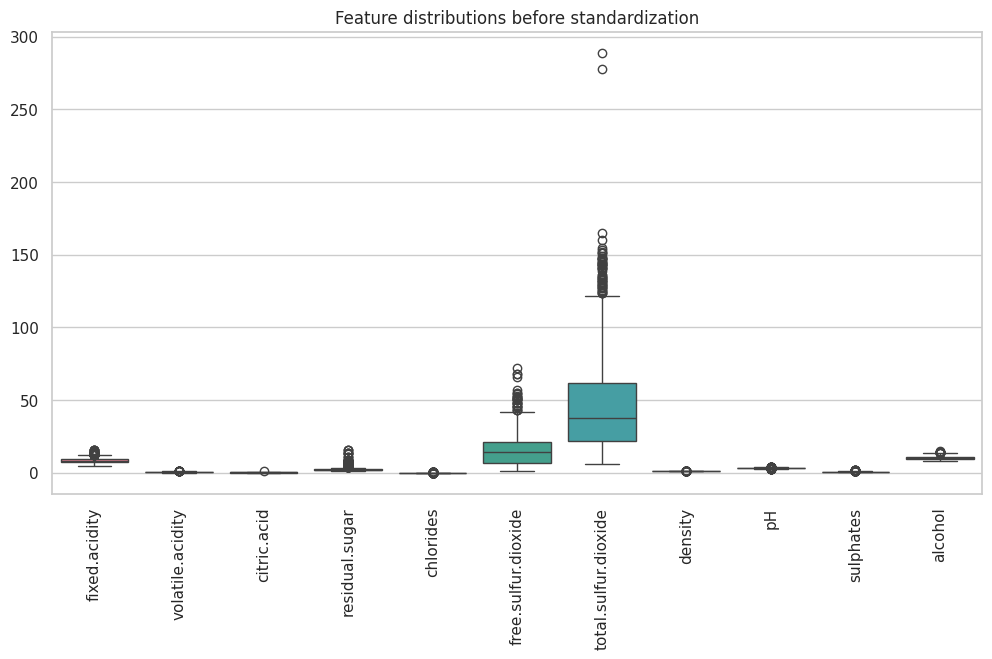

In [118]:
#Compare before and After scaling
plt.figure(figsize=(12,6))
sns.boxplot(data=x)
plt.xticks(rotation=90)
plt.title("Feature distributions before standardization")

In [119]:
"""
Before standardization, features have vastly different ranges
some variables dominate the scale
Direct distance calculations would be biased
"""

'\nBefore standardization, features have vastly different ranges\nsome variables dominate the scale\nDirect distance calculations would be biased\n'

Text(0.5, 1.0, 'Feature distribution after scaling')

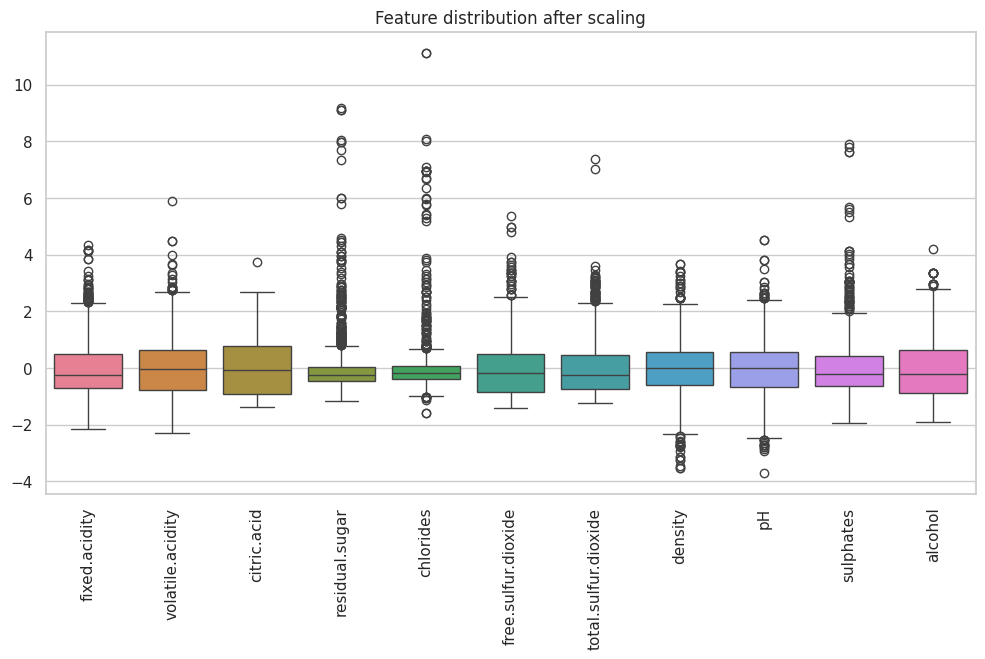

In [122]:
#After standardization
plt.figure(figsize=(12,6))
sns.boxplot(data=X_scaled)
plt.xticks(rotation=90)
plt.title("Feature distribution after scaling")

In [123]:
#analysis
"""
after standardization:
features are centered around 0
they share a comparable scale
each feature now contributes more equally to distance calculations and variance estimations
"""

'\nafter standardization:\nfeatures are centered around 0\nthey share a comparable scale\neach feature now contributes more equally to distance calculations and variance estimations\n'

In [126]:
"""
The predictor variables were seperated from the target variable and standardized using StandardScaler. 
THis ensured the differences in measurement units did not disproportionately influence dimensionality algorithms.
Verification confirmed that all standardized features have approximately zero mean and unit variance, making the dataset 
suitable for both PCA and MDS
"""


'\nThe predictor variables were seperated from the target variable and standardized using StandardScaler. \nTHis ensured the differences in measurement units did not disproportionately influence dimensionality algorithms.\nVerification confirmed that all standardized features have approximately zero mean and unit variance, making the dataset \nsuitable for both PCA and MDS\n'

In [128]:
#PCA - PRINCIPLE COMPONENT ANALYSIS

# - How much variance is captured by the first few principle components?
# - Are 2 principle components sufficient for visualization?
# - Which chemical properties contribute most to each principle component?
# - Does the PCA projection reveal any natural grouping of wine by quality?

In [130]:
from sklearn.decomposition import PCA

pca = PCA()

pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [132]:
explained_variance = pca.explained_variance_ratio_

explained_variance

array([0.28173931, 0.1750827 , 0.1409585 , 0.11029387, 0.08720837,
       0.05996439, 0.05307193, 0.03845061, 0.0313311 , 0.01648483,
       0.00541439])

In [134]:
explained_df = pd.DataFrame({
    "Principal Component": [f"PC{i + 1}" for i in range(len(explained_variance))],
    "Explained Variance" : explained_variance,
    "Cummulative Variance" : np.cumsum(explained_variance)
})

explained_df

,Principal Component,Explained Variance,Cummulative Variance
0,PC1,0.281739,0.281739
1,PC2,0.175083,0.456822
2,PC3,0.140958,0.597781
3,PC4,0.110294,0.708074
4,PC5,0.087208,0.795283
5,PC6,0.059964,0.855247
6,PC7,0.053072,0.908319
7,PC8,0.038451,0.946770
8,PC9,0.031331,0.978101
9,PC10,0.016485,0.994586


In [136]:
#how much variance does the first component explain? => 0.28
#how much variance do the first 2 components explain? => 0.456
#how many components are required to retain about 90% of the variance? => 6 components

"""
since the first 2 components capture a variance in the range of 45%-50% that is perfectly acceptable for visualization
but it tells us that the 2D projection loses a substancial amount of information.

This is one reason we will later compare PCA and MDS
"""


'\nsince the first 2 components capture a variance in the range of 45%-50% that is perfectly acceptable for visualization\nbut it tells us that the 2D projection loses a substancial amount of information.\n\nThis is one reason we will later compare PCA and MDS\n'

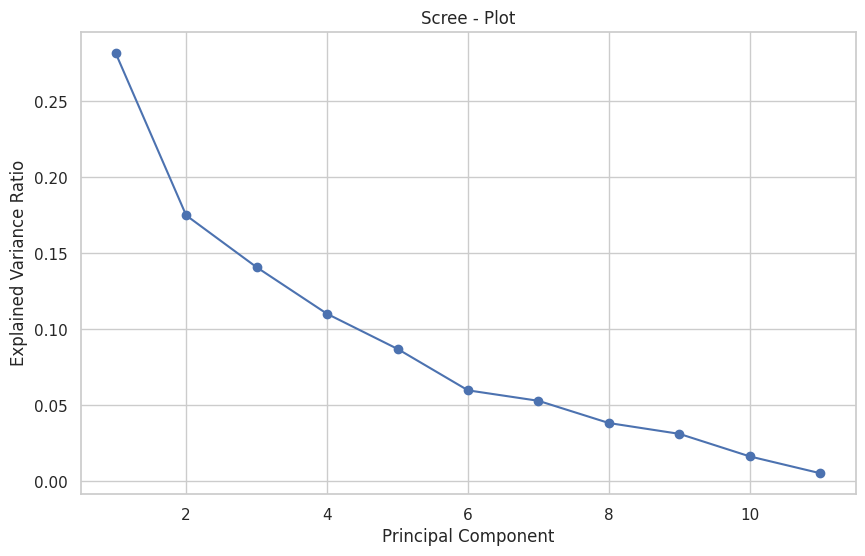

In [138]:
#Scree-plot

#a scree-plot helps visualize the contribution of each principle component

plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree - Plot")
plt.grid(True)

In [ ]:
"""
We are looking for an elbow in the above curve

- where does the curve begin to flatten? =>PC2 marks the end of the initial sharp drop but the most pronounced "elbow" where 
    the line truely flattens out (the scree) is at around 6
- is there a point after which additional components contribute very little? => yes, beyond 6
- does the scree-plot support using 2 principal components for visualization? => No, little variance is captured in 2 components
    PC1 contributes about 28.1%, PC2 contributes about 17.5% which in turn accounts for about 45.1% of the variance leaving out about 54%
    variance hence a 2D visualization would be an unreliable representation of the data
"""

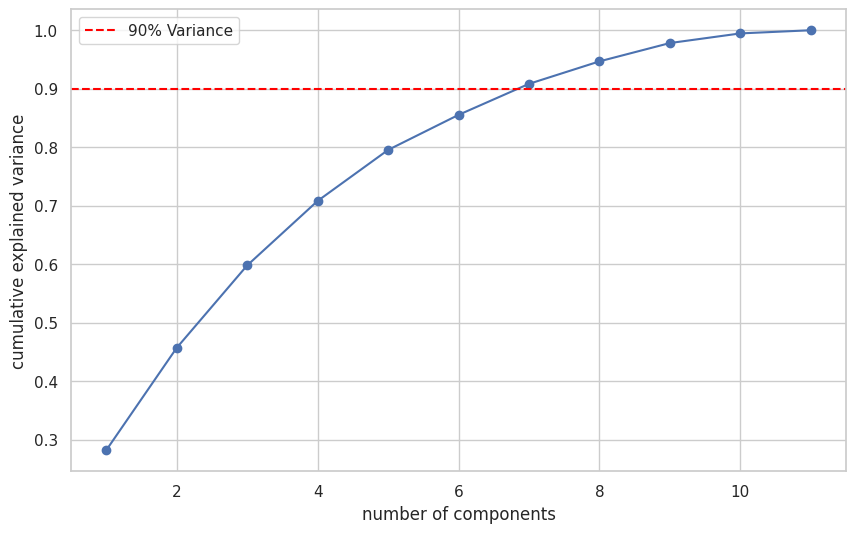

In [142]:
#cumulative explained variance

plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(explained_variance) + 1),
    np.cumsum(explained_variance),
    marker="o"
)

plt.axhline(0.90, color="red", linestyle="--", label="90% Variance")

plt.xlabel("number of components")
plt.ylabel("cumulative explained variance")

plt.legend()
plt.grid(True)


In [ ]:
"""
How many principal components are required to preserve 90% of the variance? 7 principal components
Is 2 dimensional visualization mainly for interpretation or does it retain most of the information? mainly for interpretation because
less information is retained (more than 50% of the information is not accounted for)
"""

In [148]:
## Feature loading (Loading matrix)
# - tells us how strongly each original feature contributes to each principal component

loadings = pd.DataFrame(
    pca.components_.T,
    columns = [f"PC{i+1}" for i in range(x.shape[1])],
    index=x.columns
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
fixed.acidity,0.489314,-0.110503,-0.123302,-0.229617,-0.082614,-0.101479,0.350227,0.177595,0.194021,-0.249523,0.639691
volatile.acidity,-0.238584,0.274930,-0.449963,0.078960,0.218735,-0.411449,0.533735,0.078775,-0.129110,0.365925,0.002389
citric.acid,0.463632,-0.151791,0.238247,-0.079418,-0.058573,-0.069593,-0.105497,0.377516,-0.381450,0.621677,-0.070910
residual.sugar,0.146107,0.272080,0.101283,-0.372793,0.732144,-0.049156,-0.290663,-0.299845,0.007523,0.092872,0.184030
chlorides,0.212247,0.148052,-0.092614,0.666195,0.246501,-0.304339,-0.370413,0.357009,0.111339,-0.217671,0.053065
free.sulfur.dioxide,-0.036158,0.513567,0.428793,-0.043538,-0.159152,0.014000,0.116596,0.204781,0.635405,0.248483,-0.051421
total.sulfur.dioxide,0.023575,0.569487,0.322415,-0.034577,-0.222465,-0.136308,0.093662,-0.019036,-0.592116,-0.370750,0.068702
density,0.395353,0.233575,-0.338871,-0.174500,0.157077,0.391152,0.170481,0.239223,0.020719,-0.239990,-0.567332
pH,-0.438520,0.006711,0.057697,-0.003788,0.267530,0.522116,0.025138,0.561391,-0.167746,-0.010970,0.340711
sulphates,0.242921,-0.037554,0.279786,0.550872,0.225962,0.381263,0.447469,-0.374604,-0.058367,0.112320,0.069555


In [152]:
#reducing to 2 components

pca_2d = PCA(n_components=2)

X_pca = pca_2d.fit_transform(X_scaled)

X_pca

array([[-1.61952988,  0.45095009],
       [-0.79916993,  1.85655306],
       [-0.74847909,  0.88203886],
       ...,
       [-1.45612897,  0.31174559],
       [-2.27051793,  0.97979111],
       [-0.42697475, -0.53669021]])

In [154]:
#converting into a dataframe for easier plotting

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

In [156]:
pca_df

,PC1,PC2
0,-1.619530,0.450950
1,-0.799170,1.856553
2,-0.748479,0.882039
3,2.357673,-0.269976
4,-1.619530,0.450950
...,...,...
1594,-2.150500,0.814286
1595,-2.214496,0.893101
1596,-1.456129,0.311746
1597,-2.270518,0.979791


In [158]:
pca_df["quality"] = y.values

In [160]:
pca_df

,PC1,PC2,quality
0,-1.619530,0.450950,5
1,-0.799170,1.856553,5
2,-0.748479,0.882039,5
3,2.357673,-0.269976,6
4,-1.619530,0.450950,5
...,...,...,...
1594,-2.150500,0.814286,5
1595,-2.214496,0.893101,6
1596,-1.456129,0.311746,6
1597,-2.270518,0.979791,5


Text(0.5, 1.0, 'PCA projection of wine samples')

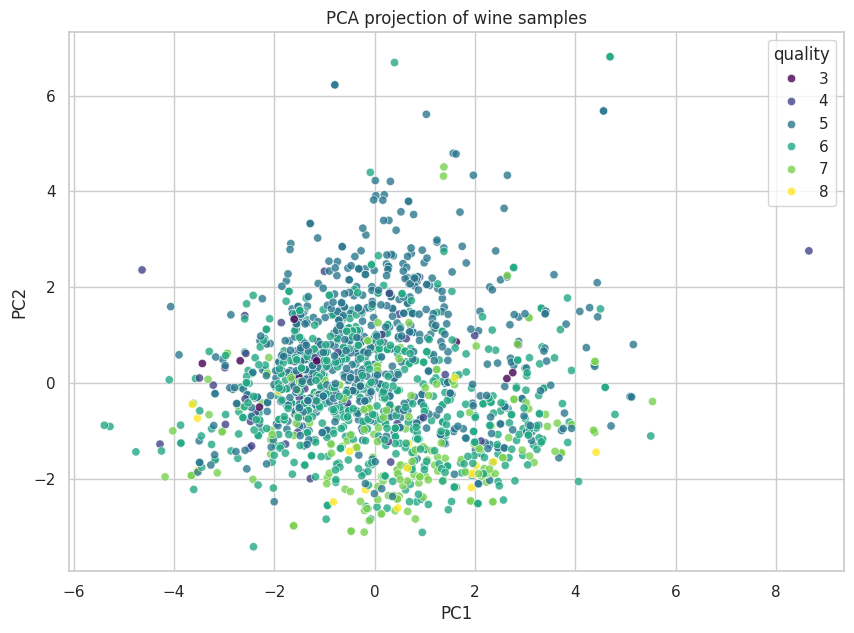

In [162]:
#visualizing the PCA projection
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="quality",
    palette="viridis",
    alpha=0.8
)

plt.title("PCA projection of wine samples")

In [ ]:
"""
- do wines with similar quality scores appear together? -yes / no
- is there overlap between quality groups? yes
- can we observe potential clusters? no
- are there isolated observations that may represent unusual batches? yes
"""


In [ ]:
#SUMMARY OF PCA
"""
PCA reduced the eleven standardized chemical measurements to two principal components that capture the largest sources of variation 
in the dataset. The first two components explain a substantial portion of the overall variance, making them suitable for visualization, 
although some information is inevitably lost. The loading matrix indicates that features such as citric acid, density, fixed acidity and pH 
contribute strongly to the principal components. The resulting scatter plot provides an initial view of the data structure, 
revealing whether wines with similar quality scores occupy similar regions of the reduced feature space.
"""